# Grid overview

This notebook gives an overview of the nested ROMS grids used to establish the Hvalfjörður model domain.

- **Grid loading**: Open the Iceland0–Iceland3 grid files.
- **Outlines**: Compute the outer boundaries of each grid from `lon_rho`/`lat_rho`.
- **Map plot**: Plot nested grid outlines on a map with coastlines to illustrate resolution and nesting.



In [1]:
import xarray as xr

In [2]:
grid0=xr.open_dataset('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland0_MARBL_2024/Iceland0_grid.nc')
grid1=xr.open_dataset('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland1_MARBL_2024/Iceland1_grid.nc')
grid2=xr.open_dataset('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland2_MARBL_2024/Iceland2_grid.nc')
grid3=xr.open_dataset('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_grid.nc')


In [3]:
#grid0.load()
#grid1.load()
#grid2.load()
grid3.load()

<xarray.Dataset> Size: 18MB
Dimensions:    (one: 1, eta_rho: 386, xi_rho: 642)
Dimensions without coordinates: one, eta_rho, xi_rho
Data variables: (12/14)
    spherical  (one) |S1 1B b'T'
    angle      (eta_rho, xi_rho) float64 2MB 0.005199 0.005199 ... -0.005232
    h          (eta_rho, xi_rho) float64 2MB 35.92 35.93 35.95 ... 5.0 5.0 5.0
    hraw       (eta_rho, xi_rho) float64 2MB 35.92 35.99 35.99 ... -0.2 -0.2
    f          (eta_rho, xi_rho) float64 2MB 0.000131 0.000131 ... 0.0001312
    pm         (eta_rho, xi_rho) float64 2MB 0.02 0.02 0.02 ... 0.02 0.02 0.02
    ...         ...
    lat_rho    (eta_rho, xi_rho) float64 2MB 64.24 64.24 64.24 ... 64.41 64.41
    mask_rho   (eta_rho, xi_rho) float64 2MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    tra_lon    (one) float64 8B -21.68
    tra_lat    (one) float64 8B 64.33
    rotate     (one) float64 8B 0.0
    xy_flip    (one) float64 8B 9.969e+36
Attributes:
    Title:    ROMS grid by Easy Grid. Settings: nx: 640 ny: 384 xsize: 32 ysi...
    Date:     09-Oct-2025
    Type:     ROMS grid produced by Easy Grid

In [5]:
ds0 = xr.open_dataset(grid_files[0])
boundary0 = get_grid_outline(ds0)

ds1 = xr.open_dataset(grid_files[1])
boundary1 = get_grid_outline(ds1)

ds2 = xr.open_dataset(grid_files[2])
boundary2 = get_grid_outline(ds2)

ds3 = xr.open_dataset(grid_files[3])
boundary3 = get_grid_outline(ds3)

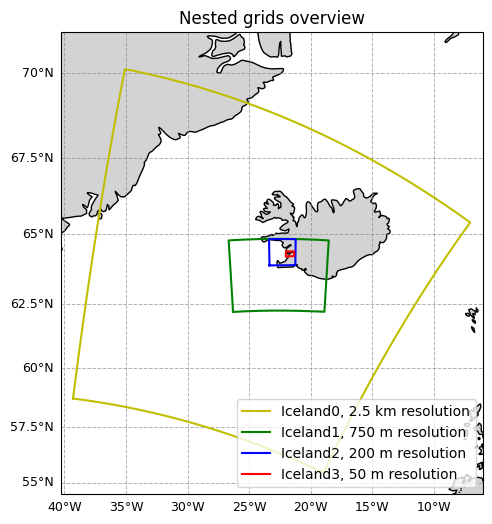

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Example: boundary is an Nx2 array (lon, lat)
# boundary = np.array([[lon1, lat1], [lon2, lat2], ...])

# Create a Cartopy map with a PlateCarree projection (suitable for lon/lat)
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.Mercator())

import cartopy.mpl.ticker as cticker

# -------------------------------------
# Add latitude / longitude gridlines
# -------------------------------------
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.7,
    color="gray",
    alpha=0.6,
    linestyle="--"
)

# Label settings
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

# Optional: nice tick formatting
gl.xformatter = cticker.LongitudeFormatter()
gl.yformatter = cticker.LatitudeFormatter()


# Add coastlines and features for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Plot the boundary line
ax.plot(boundary0[:, 0], boundary0[:, 1], '-y', transform=ccrs.PlateCarree(), label='Iceland0, 2.5 km resolution')
ax.plot(boundary1[:, 0], boundary1[:, 1], '-g', transform=ccrs.PlateCarree(), label='Iceland1, 750 m resolution')
ax.plot(boundary2[:, 0], boundary2[:, 1], '-b', transform=ccrs.PlateCarree(), label='Iceland2, 200 m resolution')
ax.plot(boundary3[:, 0], boundary3[:, 1], '-r', transform=ccrs.PlateCarree(), label='Iceland3, 50 m resolution')

# Optionally set map extent to fit your data
ax.set_extent([boundary0[:,0].min()-1, boundary0[:,0].max()+1,
               boundary0[:,1].min()-1, boundary0[:,1].max()+1],
              crs=ccrs.PlateCarree())

ax.legend(loc='lower right')
plt.title("Nested grids overview")
plt.show()
